In [ ]:
!pip install sentence-transformers torch

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [ ]:
text = "Embedding fine-tuning improves retrieval quality in RAG systems."

In [ ]:
embedding = model.encode(text)

In [ ]:
embedding

In [ ]:
import numpy as np
print("Embedding Shape:", embedding.shape)
print("First 10 Values:", np.round(embedding[:10], 6))

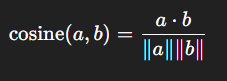

In [ ]:
import numpy as np

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

In [ ]:
documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

query = "How to improve retrieval in RAG?"

In [ ]:
doc_embs = model.encode(documents, convert_to_numpy=True)

In [ ]:
q_emb = model.encode(query, convert_to_numpy=True)

In [ ]:
scores = [cosine_sim(q_emb, d_emb) for d_emb in doc_embs]

In [ ]:
query

In [ ]:
# Print all scores
for doc, score in zip(documents, scores):
    print(f"Score: {score:.4f}  |  {doc}")

In [ ]:
pairs = [
    ("Embedding improves semantic search",
     "Fine-tuned embeddings enhance retrieval"),

    ("Embedding improves semantic search",
     "I bought a new car yesterday"),
]

In [ ]:
for s1, s2 in pairs:
    emb1, emb2 = model.encode([s1, s2], normalize_embeddings=True)
    score = cosine_sim(emb1, emb2)
    print(f"\nSentence 1: {s1}")
    print(f"Sentence 2: {s2}")
    print("Cosine Similarity:", round(score, 4))

## Keyword Search vs Vector Search

In [ ]:
import re

documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

In [ ]:
query = "How to improve retrieval in RAG?"

In [ ]:
# Tokenize function
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

In [ ]:
query_tokens = tokenize(query)

In [ ]:
query_tokens

In [ ]:

print("Query tokens:", query_tokens)


In [ ]:
print("\n=== Keyword Search Scores ===")

for doc in documents:
    doc_tokens = tokenize(doc)

    # Count matching words
    matches = set(query_tokens) & set(doc_tokens)
    score = len(matches)

    print(f"Score: {score} | Matched: {matches} | {doc}")

In [ ]:
query

In [ ]:
!pip install rank_bm25

In [ ]:
import re
from rank_bm25 import BM25Okapi

In [ ]:
documents = [
    "Embedding fine-tuning improves retrieval in RAG.",
    "LoRA reduces GPU memory usage.",
    "My car needs fuel.",
    "Vector databases store embeddings.",
]

In [ ]:

query = "How to improve retrieval in RAG?"

In [ ]:
def tokenize(text: str):
    return re.findall(r"[a-z0-9]+", text.lower())

In [ ]:
tokenized_corpus = [tokenize(d) for d in documents]
tokenized_query  = tokenize(query)

In [ ]:
tokenized_corpus

In [ ]:
tokenized_query

In [ ]:
bm25 = BM25Okapi(tokenized_corpus)

In [ ]:
scores = bm25.get_scores(tokenized_query)

In [ ]:
print("=== BM25 Scores (all docs) ===")
for doc, score in zip(documents, scores):
    print(f"{score:.4f} | {doc}")

## Evaluation of embedding mode

MTEB (Massive Text Embedding Benchmark)

STSBenchmark = Semantic Textual Similarity Benchmark

| Metric                    | Tumhara Score | Typical Range | Quality Level    | Iska Meaning                                      | Practical Impact                                   |
| ------------------------- | ------------- | ------------- | ---------------- | ------------------------------------------------- | -------------------------------------------------- |
| **Spearman (Main Score)** | **0.8203**    | 0.75 – 0.90   | 🟢 Good Baseline | Model ranking human similarity ke kaafi close hai | Semantic search me mostly relevant results milenge |
| Pearson                   | 0.8274        | 0.75 – 0.90   | 🟢 Good          | Linear similarity correlation strong hai          | Cosine similarity reliable hai                     |
| Cosine Spearman           | 0.8203        | 0.75 – 0.90   | 🟢 Good          | Cosine similarity best performing metric hai      | Retrieval me cosine use karo (recommended)         |
| Manhattan Spearman        | 0.8194        | 0.70 – 0.85   | 🟢 Good          | Slightly lower but comparable                     | Rarely used in RAG                                 |
| Euclidean Spearman        | 0.8203        | 0.75 – 0.88   | 🟢 Good          | Cosine ke almost equal                            | Acceptable alternative distance metric             |


| Score Range | Interpretation          | Typical Model Type          |
| ----------- | ----------------------- | --------------------------- |
| < 0.70      | Weak semantic alignment | Poor / old embeddings       |
| 0.70 – 0.78 | Moderate                | Small generic models        |
| 0.78 – 0.83 | **Good Baseline**       | Lightweight models (MiniLM) |
| 0.83 – 0.88 | Strong                  | Fine-tuned mid-size models  |
| 0.88+       | Very Strong / Near SOTA | Large embedding models      |


In [ ]:
!pip install mteb

In [ ]:
import mteb
from typing import Dict, Any, Optional

def eval_stsbenchmark(
    model_name: str,
    batch_size: int = 32,
    normalize_embeddings: bool = True,
    languages: Optional[list[str]] = None,
) -> Dict[str, Any]:
    """
    Evaluate any embedding model on MTEB STSBenchmark and return key metrics.
    Works with model names supported by mteb.get_model().

    Returns a dict with main metrics + raw result object.
    """
    if languages is None:
        languages = ["eng"]

    # 1) Load model via MTEB
    model = mteb.get_model(model_name)

    # 2) Get task objects
    tasks = mteb.get_tasks(tasks=["STSBenchmark"], languages=languages)

    # 3) Run evaluation
    res = mteb.evaluate(
        model,
        tasks=tasks,
        encode_kwargs={
            "batch_size": batch_size,
            "normalize_embeddings": normalize_embeddings,
        },
    )

    # 4) Extract metrics cleanly
    # res.task_results -> list[TaskResult]
    tr = next((t for t in res.task_results if t.task_name == "STSBenchmark"), None)
    if tr is None:
        raise RuntimeError("STSBenchmark TaskResult not found in results.")

    # scores structure: {'test': [ { ...metrics... } ]}
    test_entry = tr.scores["test"][0]
    out = {
        "model_name": res.model_name,
        "model_revision": res.model_revision,
        "main_score": float(test_entry["main_score"]),
        "spearman": float(test_entry["spearman"]),
        "pearson": float(test_entry["pearson"]),
        "cosine_spearman": float(test_entry["cosine_spearman"]),
        "cosine_pearson": float(test_entry["cosine_pearson"]),
        "euclidean_spearman": float(test_entry["euclidean_spearman"]),
        "manhattan_spearman": float(test_entry["manhattan_spearman"]),
        "languages": test_entry.get("languages"),
        "hf_subset": test_entry.get("hf_subset"),
        "raw": res,  # full ModelResult (in case you need it)
    }

    # Pretty print (optional)
    print("\n=== STSBenchmark (MTEB) ===")
    print(f"Model: {out['model_name']}")
    print(f"Revision: {out['model_revision']}")
    print(f"Main (Spearman): {out['main_score']:.4f}")
    print(f"Spearman: {out['spearman']:.4f} | Pearson: {out['pearson']:.4f}")
    print(
        "Cosine Spearman: {cs:.4f} | Euclidean Spearman: {es:.4f} | Manhattan Spearman: {ms:.4f}".format(
            cs=out["cosine_spearman"],
            es=out["euclidean_spearman"],
            ms=out["manhattan_spearman"],
        )
    )

    return out

E5 = Embedding from E(verything) to E(verything)

Developed by:

Microsoft Research

Popular model name:

intfloat/e5-base-v2

BGE = BAAI General Embedding

Developed by:

Beijing Academy of Artificial Intelligence

Popular models:

BAAI/bge-base-en-v1.5

In [ ]:
r1 = eval_stsbenchmark("sentence-transformers/all-MiniLM-L6-v2")
r2 = eval_stsbenchmark("BAAI/bge-base-en-v1.5")
r3 = eval_stsbenchmark("intfloat/e5-base-v2")

In [ ]:
results = [r1, r2, r3]
for r in sorted(results, key=lambda x: x["main_score"], reverse=True):
    print(f"{r['model_name']}: {r['main_score']:.4f}")

## Training Code

In [ ]:
from datasets import load_from_disk
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

In [ ]:
# Load base model
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")


In [ ]:
# with inbuilt dataset
# 2. Load dataset
# dataset = load_dataset("sentence-transformers/all-nli", "triplet")
# train_dataset = dataset["train"].select(range(100_000))
# eval_dataset = dataset["dev"]

In [ ]:
import zipfile
import os

zip_path = "/content/pharma_ft_data_backup.zip"       # zip file ka path
extract_to = "unzipped_data"     # folder jaha extract karna hai

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzip complete")

In [ ]:
# Load YOUR custom dataset
train_dataset = load_from_disk("/content/unzipped_data/pharma_ft_data/train_pairs")

Arrow file = Apache Arrow columnar format

HuggingFace Datasets internally use karta hai:

Fast memory-mapped storage

Efficient column-based access

Faster training

Low RAM usage

Parallel data loading

Isliye:
Dataset ko JSON me store nahi karta
Arrow binary format me store karta hai.

In [ ]:
print("Dataset loaded:", train_dataset)
print("Columns:", train_dataset.column_names)

In [ ]:
# Define loss (perfect for anchor-positive pairs)
loss = MultipleNegativesRankingLoss(model)

In [ ]:
# Training arguments
args = SentenceTransformerTrainingArguments(
    output_dir="models/pharma-embedding-ft",
    num_train_epochs=3,                  # increase since dataset small
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True,                           # use False if CPU
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    logging_steps=10,
    save_strategy="epoch",
)

In [ ]:
# Trainer (NO evaluator needed for pair dataset)
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
)


In [ ]:
# Train
trainer.train()

In [ ]:
# Save model
model.save_pretrained("models/pharma-embedding-ft")

print("Fine-tuned model saved successfully.")

In [ ]:
# import os
# import zipfile

# def zip_folder_manual(folder_path: str, output_zip_path: str):
#     with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         for root, dirs, files in os.walk(folder_path):
#             for file in files:
#                 file_path = os.path.join(root, file)
#                 arcname = os.path.relpath(file_path, folder_path)
#                 zipf.write(file_path, arcname)

#     print(f"[OK] Folder zipped at: {output_zip_path}")


# # Example
# zip_folder_manual("/content/models", "model_backup.zip")

## Inference code

In [ ]:
from sentence_transformers import SentenceTransformer

embeddings_model = SentenceTransformer("/content/models/pharma-embedding-ft")

sentences = [
    "How to improve RAG retrieval?",
    "LoRA reduces GPU memory."
]

embeddings = embeddings_model.encode(sentences, normalize_embeddings=True)

In [ ]:
embeddings

## now lets create a RAG and use the custom finetuned model

In [ ]:
!pip install -U langchain
# !pip install -U langchain-openai

In [ ]:
%pip install -qU langchain-community pypdf

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
# Load document using PyPDFLoader document loader
loader = PyPDFLoader("/content/unzipped_data/pharma_demo.pdf")
documents = loader.load()

In [ ]:
documents

In [ ]:
len(documents)

In [ ]:
# !pip install langchain-text-splitters

In [ ]:
# from langchain_text_splitters import CharacterTextSplitter
# splitter = CharacterTextSplitter(
#     separator="\n\n",
#     chunk_size=20,
#     chunk_overlap=15
# )

In [ ]:
# chunks = splitter.split_documents(documents)

In [ ]:
# chunks

In [ ]:
# print(len(chunks))

In [ ]:
from langchain_community.vectorstores.faiss import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# your fine-tuned SentenceTransformer model path
MODEL_PATH = "/content/models/pharma-embedding-ft"

# Embedding object (has embed_documents + embed_query)
hf_embeddings_model = HuggingFaceEmbeddings(
    model_name=MODEL_PATH,
    model_kwargs={"device": "cuda"},          # change to "cpu" if needed
    encode_kwargs={"normalize_embeddings": True}
)

In [ ]:
# !pip install -U langchain-community
from langchain_community.vectorstores.faiss import FAISS
from langchain_core.documents import Document

# 'documents' already contains Document objects from PyPDFLoader, no need to re-wrap them.
# Build FAISS from your Document list
# Make sure hf_embeddings_model is defined before this cell.
vectorstore = FAISS.from_documents(documents, hf_embeddings_model)

# Test search
query = "What are the contraindications?"
results = vectorstore.similarity_search(query, k=3)

for i, r in enumerate(results, 1):
    print(f"\n--- Result {i} ---")
    print(r.page_content[:500])

In [ ]:
!pip install -q faiss-cpu

In [ ]:
vectorstore = FAISS.from_documents(documents, hf_embeddings_model)

In [ ]:
vectorstore.save_local("faiss_index_")

In [ ]:
results = vectorstore.similarity_search("What are the warnings and precautions?", k=1)

In [ ]:
for r in results:
    print("----")
    print(r.page_content)

In [ ]:
retriever = vectorstore.as_retriever()

In [ ]:
# import os
# from google.colab import userdata
# OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
# os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [ ]:
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
!pip install -U langchain-groq

In [ ]:
from langchain_groq import ChatGroq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

llm = ChatGroq(model_name="llama-3.3-70b-versatile")

Please make sure you have added your Groq API key to the Colab secrets manager as `GROQ_API_KEY`.

In [ ]:
llm.invoke("hi")

In [ ]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    """You are a helpful assistant.
Use the following context to answer the question. If you don't know, say you don't know.

Context:
{context}

Question:
{question}

Answer:"""
)

In [ ]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [ ]:
# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
rag_chain.invoke("What are the contraindications for Amoxycillin 500 mg?")

In [ ]:
# What are the contraindications for Amoxycillin 500 mg?# How does Amoxycillin work and how is it eliminated from the body?


In [ ]:
rag_chain.invoke("How does Amoxycillin work and how is it eliminated from the body?")